### Fake News Classifier
Dataset:  https://www.kaggle.com/c/fake-news/data#

In [1]:
import pandas as pd

In [ ]:
# df1=pd.read_csv('/content/test.csv')
# df1.shape

(5200, 4)

In [ ]:
# df2=pd.read_csv('/content/submit.csv')
# df2.shape

(5200, 2)

In [ ]:
# df = pd.merge(df2, df1, on="id")


In [2]:
df=pd.read_csv('/content/merged.csv')
df.shape

(5200, 5)

In [3]:
df.tail()

,id,label,title,author,text
5195,25995,0,The Bangladeshi Traffic Jam That Never Ends - ...,Jody Rosen,Of all the dysfunctions that plague the world’...
5196,25996,1,John Kasich Signs One Abortion Bill in Ohio bu...,Sheryl Gay Stolberg,WASHINGTON — Gov. John Kasich of Ohio on Tu...
5197,25997,0,"California Today: What, Exactly, Is in Your Su...",Mike McPhate,Good morning. (Want to get California Today by...
5198,25998,1,300 US Marines To Be Deployed To Russian Borde...,NaN,« Previous - Next » 300 US Marines To Be Deplo...
5199,25999,0,"Awkward Sex, Onscreen and Off - The New York T...",Teddy Wayne,Perhaps you’ve seen the new TV series whose pi...


In [ ]:
# df.to_csv("merged.csv", index=False)


In [ ]:
# from google.colab import files

# files.download("merged.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
## Get the Independent Features

X=df.drop('label',axis=1)

In [ ]:
X.head()

,id,title,author,text
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ..."
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...


In [5]:
## Get the Dependent features
y=df['label']

In [6]:
y.head()

,label
0,0
1,1
2,0
3,1
4,1


In [10]:
df.shape

(4575, 5)

In [8]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer

In [9]:
df=df.dropna()

In [11]:
df.head(10)

,id,label,title,author,text
0,20800,0,"Specter of Trump Loosens Tongues, if Not Purse...",David Streitfeld,"PALO ALTO, Calif. — After years of scorning..."
2,20802,0,#NoDAPL: Native American Leaders Vow to Stay A...,Common Dreams,Videos #NoDAPL: Native American Leaders Vow to...
3,20803,1,"Tim Tebow Will Attempt Another Comeback, This ...",Daniel Victor,"If at first you don’t succeed, try a different..."
4,20804,1,Keiser Report: Meme Wars (E995),Truth Broadcast Network,42 mins ago 1 Views 0 Comments 0 Likes 'For th...
6,20806,1,Pelosi Calls for FBI Investigation to Find Out...,Pam Key,"Sunday on NBC’s “Meet the Press,” House Minori..."
7,20807,1,Weekly Featured Profile – Randy Shannon,Trevor Loudon,You are here: Home / *Articles of the Bound* /...
10,20810,0,184 U.S. generals and admirals endorse Trump f...,Dr. Eowyn,Have you seen that pro-Hillary TV ad of disgra...
11,20811,1,“Working Class Hero” by John Brennon,Doug Diamond,"Source: CNBC, article by Robert Ferris Arctic ..."
12,20812,0,The Rise of Mandatory Vaccinations Means the E...,Shaun Bradley,Written by Shaun Bradley Mandatory vaccinati...
13,20813,1,Communists Terrorize Small Business,Steve Watson,Store Communists Terrorize Small Business The ...


In [12]:
messages=df.copy()

In [13]:
messages.reset_index(inplace=True)

In [14]:
messages.head(10)

,index,id,label,title,author,text
0,0,20800,0,"Specter of Trump Loosens Tongues, if Not Purse...",David Streitfeld,"PALO ALTO, Calif. — After years of scorning..."
1,2,20802,0,#NoDAPL: Native American Leaders Vow to Stay A...,Common Dreams,Videos #NoDAPL: Native American Leaders Vow to...
2,3,20803,1,"Tim Tebow Will Attempt Another Comeback, This ...",Daniel Victor,"If at first you don’t succeed, try a different..."
3,4,20804,1,Keiser Report: Meme Wars (E995),Truth Broadcast Network,42 mins ago 1 Views 0 Comments 0 Likes 'For th...
4,6,20806,1,Pelosi Calls for FBI Investigation to Find Out...,Pam Key,"Sunday on NBC’s “Meet the Press,” House Minori..."
5,7,20807,1,Weekly Featured Profile – Randy Shannon,Trevor Loudon,You are here: Home / *Articles of the Bound* /...
6,10,20810,0,184 U.S. generals and admirals endorse Trump f...,Dr. Eowyn,Have you seen that pro-Hillary TV ad of disgra...
7,11,20811,1,“Working Class Hero” by John Brennon,Doug Diamond,"Source: CNBC, article by Robert Ferris Arctic ..."
8,12,20812,0,The Rise of Mandatory Vaccinations Means the E...,Shaun Bradley,Written by Shaun Bradley Mandatory vaccinati...
9,13,20813,1,Communists Terrorize Small Business,Steve Watson,Store Communists Terrorize Small Business The ...


In [15]:
messages['title'][6]

'184 U.S. generals and admirals endorse Trump for Commander-In-Chief'

In [18]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [19]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import re
import nltk
ps = PorterStemmer()
corpus = []
for i in range(0, len(messages)):
    review = re.sub('[^a-zA-Z]', ' ', messages['title'][i])
    review = review.lower()
    review = review.split()

    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)
    corpus.append(review)

In [22]:
corpus

['specter trump loosen tongu purs string silicon valley new york time',
 'nodapl nativ american leader vow stay winter file lawsuit polic',
 'tim tebow attempt anoth comeback time basebal new york time',
 'keiser report meme war e',
 'pelosi call fbi investig find russian donald trump breitbart',
 'weekli featur profil randi shannon',
 'u gener admir endors trump command chief',
 'work class hero john brennon',
 'rise mandatori vaccin mean end medic freedom',
 'communist terror small busi',
 'comput programm come forward admit paid rig vote booth trump right usa newsflash',
 'thiev take chunk chang pound berlin museum new york time',
 'new england patriot owner still sore n f l payback sight new york time',
 'colleg republican yaf sue berkeley ann coulter event breitbart',
 'trump melt accus us postal servic steal elect clinton',
 'visit madagascar leav red swimsuit lemur recip home new york time',
 'rees peanut butter cup cheap full toxic chemic',
 'presid obama presid elect donald tr

In [23]:
## Applying Countvectorizer
# Creating the Bag of Words model
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000,ngram_range=(1,3)) # take most 5000 words, take combination 1,2or 3 words for making vector
X = cv.fit_transform(corpus).toarray()

In [24]:
X.shape

(4575, 5000)

In [25]:
y=messages['label']

In [26]:
## Divide the dataset into Train and Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

In [28]:
cv.get_feature_names_out()[:20]

array(['aaron', 'abandon', 'abba', 'abbi', 'abbi martin',
       'abbi martin expos', 'abc', 'abe', 'abedin', 'abedin email',
       'abolish', 'abort', 'abram', 'abroad', 'abroad new',
       'abroad new york', 'absolut', 'abus', 'academi', 'accept'],
      dtype=object)

In [31]:
cv.get_params()

{'analyzer': 'word',
 'binary': False,
 'decode_error': 'strict',
 'dtype': numpy.int64,
 'encoding': 'utf-8',
 'input': 'content',
 'lowercase': True,
 'max_df': 1.0,
 'max_features': 5000,
 'min_df': 1,
 'ngram_range': (1, 3),
 'preprocessor': None,
 'stop_words': None,
 'strip_accents': None,
 'token_pattern': '(?u)\\b\\w\\w+\\b',
 'tokenizer': None,
 'vocabulary': None}

In [32]:
count_df = pd.DataFrame(X_train, columns=cv.get_feature_names_out())

In [33]:
count_df.head()

,aaron,abandon,abba,abbi,abbi martin,abbi martin expos,abc,abe,abedin,abedin email,...,zero,zika,zika new,zika new york,zika viru,zimbabw,zone,zone new,zone new york,zuckerberg
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
import matplotlib.pyplot as plt

In [37]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    See full source and example:
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

### MultinomialNB Algorithm

In [35]:

from sklearn.naive_bayes import MultinomialNB
classifier=MultinomialNB()

In [36]:
from sklearn import metrics
import numpy as np
import itertools

accuracy:   0.761
Confusion matrix, without normalization


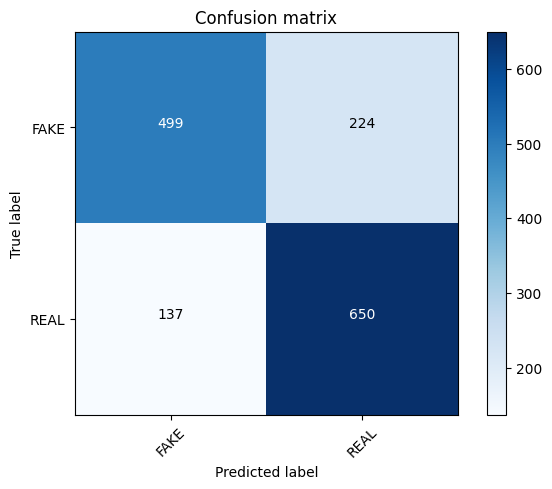

In [38]:
classifier.fit(X_train, y_train)
pred = classifier.predict(X_test)
score = metrics.accuracy_score(y_test, pred)
print("accuracy:   %0.3f" % score)
cm = metrics.confusion_matrix(y_test, pred)
plot_confusion_matrix(cm, classes=['FAKE', 'REAL'])

In [39]:
classifier.fit(X_train, y_train)
pred = classifier.predict(X_test)
score = metrics.accuracy_score(y_test, pred)
score

0.7609271523178808

In [40]:
y_train.shape

(3065,)

### Passive Aggressive Classifier Algorithm

In [44]:
from sklearn.linear_model import PassiveAggressiveClassifier # this algo is mostly used to deal with text data
# The n_iter parameter was deprecated and removed; use max_iter instead.
linear_clf = PassiveAggressiveClassifier(max_iter=50)

accuracy:   0.693
Confusion matrix, without normalization


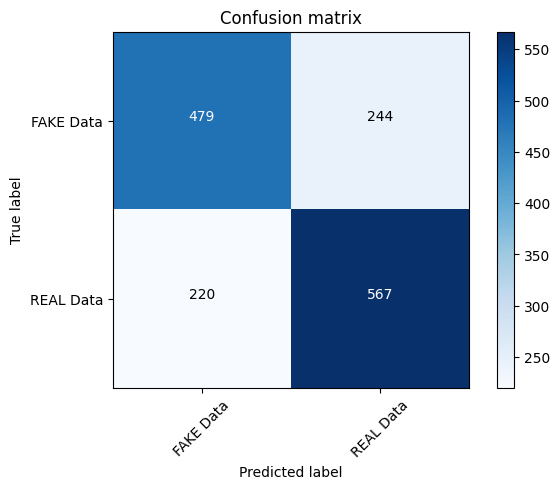

In [45]:
linear_clf.fit(X_train, y_train)
pred = linear_clf.predict(X_test)
score = metrics.accuracy_score(y_test, pred)
print("accuracy:   %0.3f" % score)
cm = metrics.confusion_matrix(y_test, pred)
plot_confusion_matrix(cm, classes=['FAKE Data', 'REAL Data'])

### Multinomial Classifier with Hyperparameter

In [46]:
classifier=MultinomialNB(alpha=0.1)

In [47]:
previous_score=0
for alpha in np.arange(0,1,0.1):
    sub_classifier=MultinomialNB(alpha=alpha)
    sub_classifier.fit(X_train,y_train)
    y_pred=sub_classifier.predict(X_test)
    score = metrics.accuracy_score(y_test, y_pred)
    if score>previous_score:
        classifier=sub_classifier
    print("Alpha: {}, Score : {}".format(alpha,score))

/usr/local/lib/python3.12/dist-packages/sklearn/naive_bayes.py:898: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Alpha: 0.0, Score : 0.47880794701986756
Alpha: 0.1, Score : 0.7423841059602649
Alpha: 0.2, Score : 0.7509933774834437
Alpha: 0.30000000000000004, Score : 0.7529801324503311
Alpha: 0.4, Score : 0.7529801324503311
Alpha: 0.5, Score : 0.7549668874172185
Alpha: 0.6000000000000001, Score : 0.756953642384106
Alpha: 0.7000000000000001, Score : 0.7589403973509934
Alpha: 0.8, Score : 0.7576158940397351
Alpha: 0.9, Score : 0.7589403973509934


In [48]:
## Get Features names
feature_names = cv.get_feature_names_out()

In [50]:
classifier.feature_log_prob_[0] # most negative value says most fakest word. less negative --> real word not fake

array([-10.08135476,  -9.33414036, -10.08135476, ...,  -8.91128351,
        -8.91128351,  -9.33414036])

In [51]:
### Most real
sorted(zip(classifier.feature_log_prob_[0], feature_names), reverse=True)[:20]

[(np.float64(-3.0895647510554918), 'new'),
 (np.float64(-3.156087054913935), 'york'),
 (np.float64(-3.156087054913935), 'new york'),
 (np.float64(-3.15827308704472), 'time'),
 (np.float64(-3.173710597282974), 'york time'),
 (np.float64(-3.173710597282974), 'new york time'),
 (np.float64(-4.389120186912399), 'trump'),
 (np.float64(-5.58278041925843), 'donald'),
 (np.float64(-5.58278041925843), 'breitbart'),
 (np.float64(-5.595218390550648), 'donald trump'),
 (np.float64(-5.686905604308264), 'clinton'),
 (np.float64(-5.883317738201473), 'hillari'),
 (np.float64(-5.952429863161823), 'elect'),
 (np.float64(-6.007590904458623), 'say'),
 (np.float64(-6.106878738906007), 'obama'),
 (np.float64(-6.341043131234496), 'presid'),
 (np.float64(-6.3677826922763945), 'hillari clinton'),
 (np.float64(-6.395256947828644), 'state'),
 (np.float64(-6.4235074141144946), 'brief'),
 (np.float64(-6.513388233532078), 'brief new york')]

In [52]:
### Most fake
sorted(zip(classifier.feature_log_prob_[0], feature_names))[:5000]

[(np.float64(-10.081354758980703), 'aaron'),
 (np.float64(-10.081354758980703), 'abba'),
 (np.float64(-10.081354758980703), 'abbi'),
 (np.float64(-10.081354758980703), 'abbi martin'),
 (np.float64(-10.081354758980703), 'abbi martin expos'),
 (np.float64(-10.081354758980703), 'abedin'),
 (np.float64(-10.081354758980703), 'abedin email'),
 (np.float64(-10.081354758980703), 'abolish'),
 (np.float64(-10.081354758980703), 'abram'),
 (np.float64(-10.081354758980703), 'access pipelin'),
 (np.float64(-10.081354758980703), 'accid'),
 (np.float64(-10.081354758980703), 'accident'),
 (np.float64(-10.081354758980703), 'adopt'),
 (np.float64(-10.081354758980703), 'advertis'),
 (np.float64(-10.081354758980703), 'affect'),
 (np.float64(-10.081354758980703), 'afraid'),
 (np.float64(-10.081354758980703), 'ago'),
 (np.float64(-10.081354758980703), 'ahca'),
 (np.float64(-10.081354758980703), 'ahmad'),
 (np.float64(-10.081354758980703), 'aim'),
 (np.float64(-10.081354758980703), 'album'),
 (np.float64(-10.

In [53]:
# what is Passive Aggressive Classifier Algorithm
# what is MultinomialNB Algorithm
# what is hashing vector? --> algo to convert text into embeddings
